In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot(xs, ys_alg1, ys_alg24, plot_path, palette=None, dataset="dataset"):
    xs = np.asarray(xs)
    y1 = np.asarray(ys_alg1, dtype=float)
    y2 = np.asarray(ys_alg24, dtype=float)

    # keep log-safe
    def _safe_log(arr):
        if np.any(arr <= 0):
            pos_min = arr[arr > 0].min() if np.any(arr > 0) else 1e-6
            eps = max(pos_min * 1e-3, 1e-9)
            return np.where(arr <= 0, eps, arr)
        return arr

    y1 = _safe_log(y1)
    y2 = _safe_log(y2)

    # dark blue & dark orange by default (avoid seaborn defaults)
    if palette is None:
        palette = ["#1f3a93", "#d35400"]


    #sns.set(rc={"axes.labelweight": "bold"})  # bold axis labels

    fig, ax = plt.subplots(figsize=(6.4, 4.6), facecolor="white")
    ax.plot(xs, y1, marker="o", linewidth=6, label="CD", zorder=3)
    ax.plot(xs, y2, marker="s", linewidth=6, linestyle="--", label="MI", zorder=3)

    ax.axhline(0.0, color="black", linewidth=1.2)
    # labels & scale
    ax.set_xlabel("Number of attributes", fontweight="bold", fontsize=22)
    ax.set_ylabel("Times (s) -log scale", fontweight="bold", fontsize=18)
    ax.set_yscale("log")
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold"); lbl.set_fontsize(18)

    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold"); lbl.set_fontsize(18)

    # integer ticks only (no 0.5)
    xs_int = np.asarray(xs, dtype=int)
    ax.set_xticks(xs_int)
    ax.set_xticklabels([str(v) for v in xs_int])
    ax.margins(x=0.02)

    # title: only first letter uppercase
    if isinstance(dataset, str) and dataset:
        title_text = dataset[0].upper() + dataset[1:]
    else:
        title_text = str(dataset)
    ax.set_title(title_text, fontweight="bold")

    ax.legend(loc="upper left", frameon=True)
    fig.tight_layout()
    #fig.savefig(plot_path, dpi=160)
    plt.show()
    plt.close(fig)


In [17]:
#read data from file
dataset="census"
import pandas as pd
import os
PATH="../tables/"
df=pd.read_csv(os.path.join(PATH,f"{dataset}_3_time_vs_num_attrs.csv"))
df.head()

,timestamp,k_attrs,cols_json,domain_size,levels_json,probs_json,time_alg1_first_s,num_edges_alg1,time_alg2_s,time_alg4_s,time_alg24_s,q_base_groups,q_star_groups,merges_alg2,utility_q_babble,utility_q_base,utility_q_star,kept_q_babble,kept_q_base,kept_q_star
0,2025-10-13 13:02:03,1,"[""sex""]",2,"[0.6666666666666666, 0.6666666666666666, 0.333...","[0.25, 0.25, 0.25, 0.25]",0.000015,0,0.000020,0.000017,0.000036,1,1,1,0.666667,0.666667,0.666667,1,1,1
1,2025-10-13 13:02:03,2,"[""sex"", ""race""]",10,"[0.9090909090909091, 0.7272727272727273, 0.454...","[0.25, 0.25, 0.25, 0.25]",0.000045,32,0.000115,0.000368,0.000482,9,5,1,2.000000,1.727273,2.000000,5,3,5
2,2025-10-13 13:02:04,3,"[""sex"", ""race"", ""education_num""]",160,"[0.9937888198757764, 0.7453416149068323, 0.496...","[0.25, 0.25, 0.25, 0.25]",0.023730,8618,0.021762,0.912999,0.934761,159,2,1,37.347826,36.658385,47.770186,73,52,78


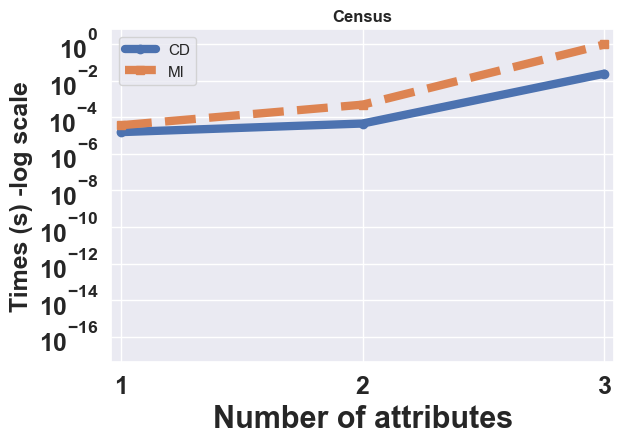

In [18]:
#drop the row with max ys_alg24

xs=df["k_attrs"].tolist()
ys_alg1=df["time_alg1_first_s"].tolist()
ys_alg24=df["time_alg24_s"].tolist()
#make milisecond second

#keep on 3 values in ys_alg24, xs, ys_alg1
ys_alg1=ys_alg1[:3]
ys_alg24=ys_alg24[:3]
xs=xs[:3]

plot(xs, ys_alg1, ys_alg24, f"{dataset}_time_vs_num_attrs.png",dataset=dataset)

In [9]:
#read data from file
df=pd.read_csv("/Users/aryal/Desktop/Querying-COI/data/real/compas.csv")
#unique values
df.nunique()

id                         7214
name                       7158
first                      2800
last                       3950
compas_screening_date       690
sex                           2
dob                        5452
age                          65
age_cat                       3
race                          6
juv_fel_count                11
decile_score                 10
juv_misd_count               10
juv_other_count              10
priors_count                 37
days_b_screening_arrest     423
c_jail_in                  6907
c_jail_out                 6880
c_case_number              7192
c_offense_date              927
c_arrest_date               580
c_days_from_compas          499
c_charge_degree               2
c_charge_desc               437
is_recid                      2
r_case_number              3471
r_charge_degree              10
r_days_from_arrest          201
r_offense_date             1075
r_charge_desc               340
r_jail_in                   972
r_jail_o